# Top 100 UK bands: origins, scale and population

This popularity-first experiment starts with the 100 UK groups with the
largest captured Spotify monthly-listener counts in a frozen candidate
universe. It then asks two questions in sequence:

1. Where is the selected popularity concentrated before adjusting for
   population?
2. How does the result change when each origin is mapped to an OECD/EU
   Functional Urban Area (FUA) and divided by its 2021 population?

The second question brings **Crawley** to the top because The Cure has a large
global audience relative to Crawley's population. That is a valid
population-normalized output result, but it is based on one selected band—not
evidence of a deep local scene.

In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "reference/uk_fua_top20_2021.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the uk-music-cities repository root")

import sys
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from python_uk_bands.popularity_first_visuals import (
    add_raw_reach_rank,
    plot_multiband_stability,
    plot_population_adjusted_fua_reach,
    plot_raw_fua_reach,
    plot_raw_vs_normalized_fua_ranks,
    plot_top_selected_bands,
)
from python_uk_bands.visuals import apply_chart_style

SNAPSHOT_ID = "20260718T204522Z"
BANDS_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_bands.csv"
ORIGINS_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_origins.csv"
MAPPING_AUDIT_PATH = ROOT / "data/interim/popularity_first_top100_20260718T204522Z_fua_mapping_audit.csv"
STRICT_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_population_strict.csv"
EXTENDED_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_population_extended.csv"
SELECTION_REPORT_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_report.json"
POPULATION_REPORT_PATH = ROOT / "data/processed/popularity_first_top100_20260718T204522Z_population_adjusted_report.json"
CHART_OUTPUT_DIR = ROOT / "artifacts/experiments/top100_popularity_first_fua/20260718T204522Z"

bands = pd.read_csv(BANDS_PATH, keep_default_na=False)
origins = pd.read_csv(ORIGINS_PATH, keep_default_na=False)
mapping_audit = pd.read_csv(MAPPING_AUDIT_PATH, keep_default_na=False)
strict = pd.read_csv(STRICT_PATH, keep_default_na=False)
extended = pd.read_csv(EXTENDED_PATH, keep_default_na=False)
selection_report = json.loads(SELECTION_REPORT_PATH.read_text(encoding="utf-8"))
population_report = json.loads(
    POPULATION_REPORT_PATH.read_text(encoding="utf-8")
)
ranked_strict = add_raw_reach_rank(strict)

assert len(bands) == 100
assert bands["popularity_rank"].tolist() == list(range(1, 101))
assert bands["returned_spotify_id"].nunique() == 100
assert origins["band_count"].sum() == 100
assert len(mapping_audit) == 100
assert strict["fua_code"].nunique() == len(strict) == 20
assert (strict["population"] > 0).all()
assert strict.iloc[0]["study_city_label"] == "Crawley"
assert set(mapping_audit["popularity_rank"]) == set(range(1, 101))

apply_chart_style()
CHART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

captured_at = pd.Timestamp(bands["stats_extracted_at_utc"].iloc[0])
snapshot_date = captured_at.strftime("%-d %B %Y")
display(Markdown(
    f"**Frozen Spotify snapshot:** `{SNAPSHOT_ID}` "
    f"({captured_at.isoformat()}) · **100 selected groups** · "
    f"**OECD/EU FUA population:** {population_report['population_year']} · "
    "**Notebook execution makes no network calls**"
))

**Frozen Spotify snapshot:** `20260718T204522Z` (2026-07-18T20:45:22.974241+00:00) · **100 selected groups** · **OECD/EU FUA population:** 2021 · **Notebook execution makes no network calls**

## 01. Study design

This is a **popularity-first** study. It can find globally prominent acts from
places outside the largest-city panel—Radiohead/Oxford and The Cure/Crawley are
exactly the cases this design is meant to surface.

It is not the same study as the balanced city-first notebook:

- **Popularity-first:** select bands by captured reach → map origins → compare
  geographic concentration and output relative to population.
- **City-first:** select a fixed city universe → curate the same number of
  bands per city → compare population-normalized scene output.

The popularity-first design is best read as the geography of this selected top
100. It does not estimate the full output or scene depth of every FUA.

In [2]:
design = pd.DataFrame(
    [
        {
            "view": "Raw origin concentration",
            "numerator": "Selected band count and captured global reach",
            "denominator": "None",
            "interpretation": "Where this selected top 100 is concentrated",
        },
        {
            "view": "Population-adjusted output (main FUA view)",
            "numerator": "Captured global reach of strictly mapped bands",
            "denominator": "2021 OECD/EU FUA population",
            "interpretation": "Selected reach represented per FUA resident",
        },
        {
            "view": "Multi-band stability diagnostic",
            "numerator": "Same population-adjusted output",
            "denominator": "Same FUA population; display requires n ≥ 2",
            "interpretation": "Which results are not determined by one band",
        },
    ]
)
display(design.style.hide(axis="index"))

view,numerator,denominator,interpretation
Raw origin concentration,Selected band count and captured global reach,None,Where this selected top 100 is concentrated
Population-adjusted output (main FUA view),Captured global reach of strictly mapped bands,2021 OECD/EU FUA population,Selected reach represented per FUA resident
Multi-band stability diagnostic,Same population-adjusted output,Same FUA population; display requires n ≥ 2,Which results are not determined by one band


## 02. Frozen sources, selection and coverage

The band candidate frame comes from an archived Wikidata query for UK musical
groups with Spotify artist IDs. Spotify monthly listeners were captured once,
then identity mismatches, redirects, orchestras and origin assignments were
reviewed. Execution below reads those frozen local outputs only.

The population denominator is the
[OECD definition of cities and Functional Urban Areas](https://www.oecd.org/en/data/datasets/oecd-definition-of-cities-and-functional-urban-areas.html)
and its
[Data Explorer population series](https://data-explorer.oecd.org/vis?df%5Bag%5D=OECD.CFE.EDS&df%5Bds%5D=dsDisseminateFinalDMZ&df%5Bid%5D=DSD_FUA_DEMO%40DF_AGE_SEX&lc=en)
for 2021. The main adjusted result uses the conservative **strict**
origin-to-FUA mapping; a broader reviewed mapping is retained only as a
sensitivity check.

In [3]:
lineage = pd.DataFrame(
    [
        {
            "stage": "Candidate universe",
            "frozen input": selection_report["inputs"]["candidates"],
            "rule": "Archived Wikidata UK musical-group query",
        },
        {
            "stage": "Spotify reach capture",
            "frozen input": selection_report["inputs"]["metrics"],
            "rule": "One timestamped monthly-listener capture",
        },
        {
            "stage": "Identity and origin review",
            "frozen input": selection_report["inputs"]["overrides"],
            "rule": "Reviewed aliases, exclusions and origin overrides",
        },
        {
            "stage": "Origin → FUA audit",
            "frozen input": population_report["inputs"]["mapping"],
            "rule": "Strict, reviewed-extended or excluded decision",
        },
        {
            "stage": "Population denominator",
            "frozen input": population_report["inputs"]["population"],
            "rule": "OECD/EU FUA population, 2021",
        },
    ]
)
display(lineage.style.hide(axis="index"))

selection_qa = pd.DataFrame(
    [
        ("Candidate Spotify IDs", selection_report["candidate_ids"]),
        ("Pages with listener metrics", selection_report["metrics_rows"]),
        ("Pages without listener metrics", selection_report["metric_failures"]),
        ("Name mismatches sent to review", selection_report["identity_name_reviews"]),
        ("Accepted identities after review", selection_report["identity_accepted_rows"]),
        ("Orchestra rows excluded", selection_report["orchestra_rows_excluded"]),
        ("Redirect duplicates removed", selection_report["redirect_duplicate_rows"]),
        ("Selected groups", selection_report["selected_bands"]),
        ("Selected groups with resolved origins", selection_report["origin_resolved_bands"]),
    ],
    columns=["selection check", "count"],
)
display(selection_qa.style.hide(axis="index"))

stage,frozen input,rule
Candidate universe,data/interim/uk_group_spotify_candidates_20260718T201100Z.csv,Archived Wikidata UK musical-group query
Spotify reach capture,data/processed/uk_group_spotify_metrics_20260718T204522Z.csv,One timestamped monthly-listener capture
Identity and origin review,reference/popularity_first_overrides_20260718.csv,"Reviewed aliases, exclusions and origin overrides"
Origin → FUA audit,reference/popularity_first_origin_fua_mapping_20260718.csv,"Strict, reviewed-extended or excluded decision"
Population denominator,data/processed/uk_fua_population_2021_20260718T201304Z.csv,"OECD/EU FUA population, 2021"


selection check,count
Candidate Spotify IDs,1775
Pages with listener metrics,1749
Pages without listener metrics,26
Name mismatches sent to review,121
Accepted identities after review,1630
Orchestra rows excluded,47
Redirect duplicates removed,7
Selected groups,100
Selected groups with resolved origins,100


In [4]:
strict_coverage = population_report["strict_mapping"]
extended_coverage = population_report["extended_mapping_sensitivity"]
coverage = pd.DataFrame(
    [
        {
            "mapping view": "Strict (main)",
            "mapped bands": strict_coverage["mapped_bands"],
            "band coverage": strict_coverage["mapped_band_share"],
            "captured-reach coverage": strict_coverage["mapped_listener_reach_share"],
            "mapped FUAs": strict_coverage["mapped_fuas"],
        },
        {
            "mapping view": "Reviewed extended (sensitivity)",
            "mapped bands": extended_coverage["mapped_bands"],
            "band coverage": extended_coverage["mapped_band_share"],
            "captured-reach coverage": extended_coverage["mapped_listener_reach_share"],
            "mapped FUAs": extended_coverage["mapped_fuas"],
        },
    ]
)
display(
    coverage.style.hide(axis="index").format(
        {
            "band coverage": "{:.1%}",
            "captured-reach coverage": "{:.1%}",
        }
    )
)

mapping view,mapped bands,band coverage,captured-reach coverage,mapped FUAs
Strict (main),87,87.0%,89.0%,20
Reviewed extended (sensitivity),94,94.0%,94.7%,24


## 03. The selected top 100

Monthly listeners measure current global Spotify reach, not historical
importance or local listening. The chart shows the top 20 for orientation;
the complete table keeps the cutoff and origin decision auditable.

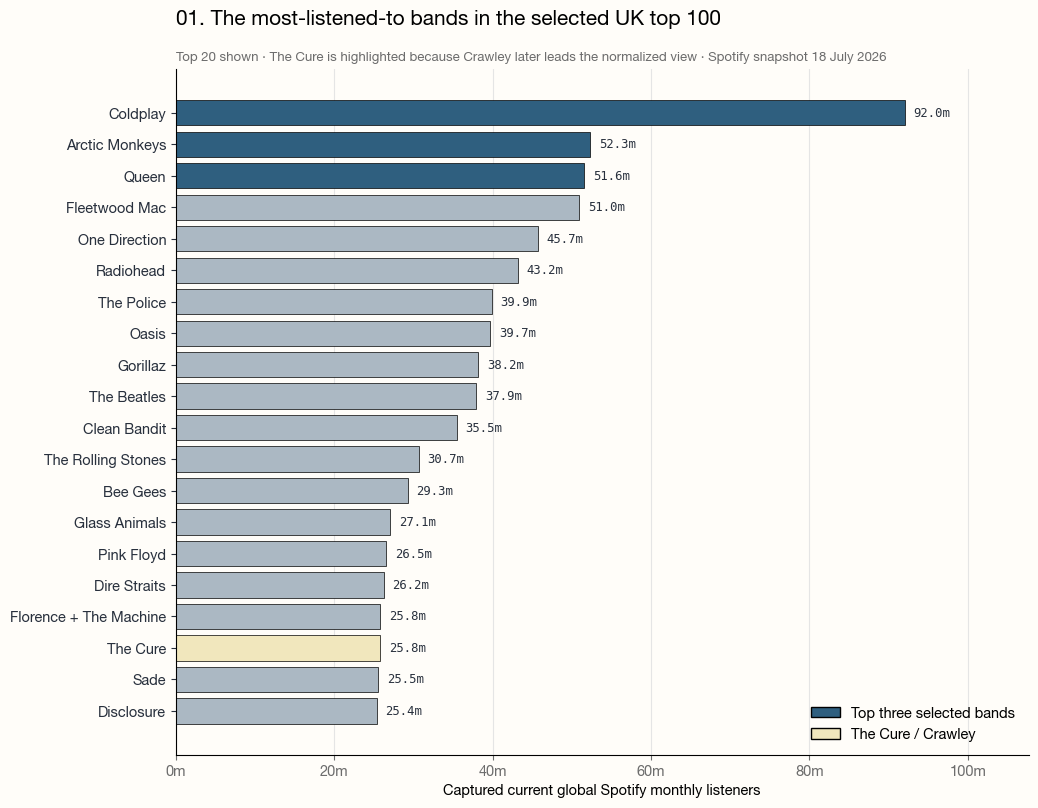

Exported to `artifacts/experiments/top100_popularity_first_fua/20260718T204522Z/chart_01_top_selected_bands.png`.

In [5]:
figure_01_path = plot_top_selected_bands(
    bands,
    snapshot_date=snapshot_date,
    output_dir=CHART_OUTPUT_DIR,
)
display(Markdown(f"Exported to `{figure_01_path.relative_to(ROOT)}`."))

In [6]:
top100_table = bands[
    [
        "popularity_rank",
        "spotify_name",
        "monthly_listeners",
        "formation_label",
        "origin_cluster",
        "origin_resolution",
    ]
].rename(
    columns={
        "popularity_rank": "Rank",
        "spotify_name": "Band / group",
        "monthly_listeners": "Captured monthly listeners",
        "formation_label": "Reported formation place",
        "origin_cluster": "Reviewed origin cluster",
        "origin_resolution": "Origin rule",
    }
)
display(
    top100_table.style.hide(axis="index").format(
        {"Captured monthly listeners": "{:,.0f}"}
    )
)

Rank,Band / group,Captured monthly listeners,Reported formation place,Reviewed origin cluster,Origin rule
1,Coldplay,"92,034,104",London,London,reported_place
2,Arctic Monkeys,"52,301,870",Sheffield,Sheffield,reported_place
3,Queen,"51,601,234",London,London,reported_place
4,Fleetwood Mac,"50,959,935",London,London,reported_place
5,One Direction,"45,724,043",London,London,reported_place
6,Radiohead,"43,168,156",Abingdon-on-Thames,Oxford,editorial_city_cluster
7,The Police,"39,887,109",London,London,reported_place
8,Oasis,"39,676,473",Manchester,Manchester,reported_place
9,Gorillaz,"38,173,160",London,London,reported_place
10,The Beatles,"37,927,636",Liverpool,Liverpool,reported_place


## 04. Raw geographic concentration

Before population enters the calculation, London dominates the selected
sample: 44 of the 100 bands and almost half of captured listener reach. The
chart below moves from editorial origin clusters to the 20 strictly mapped
FUAs so the raw and normalized rankings later use the same geographic rows.

Origin cluster,Selected bands,Captured monthly listeners,Band share,Reach share
London,44,"802,923,815",44.0%,49.5%
Manchester,11,"165,910,277",11.0%,10.2%
Birmingham,5,"56,059,884",5.0%,3.5%
Sheffield,4,"82,887,435",4.0%,5.1%
Liverpool,3,"50,053,015",3.0%,3.1%
Oxford,2,"70,261,364",2.0%,4.3%
Cambridge,2,"41,124,400",2.0%,2.5%
Glasgow,2,"20,436,452",2.0%,1.3%
Bristol,2,"14,651,842",2.0%,0.9%
Leeds,2,"13,877,184",2.0%,0.9%


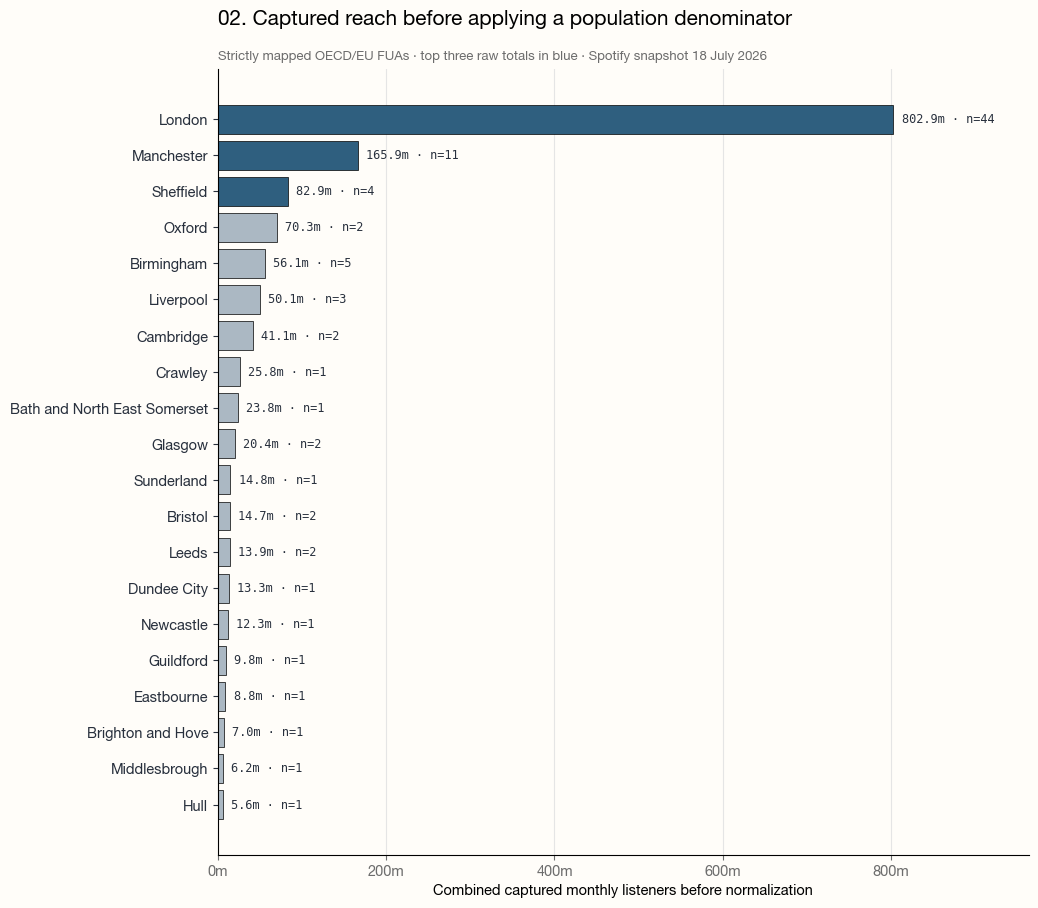

Exported to `artifacts/experiments/top100_popularity_first_fua/20260718T204522Z/chart_02_raw_fua_reach.png`.

In [7]:
origin_table = origins.head(15).rename(
    columns={
        "origin_cluster": "Origin cluster",
        "band_count": "Selected bands",
        "monthly_listeners_total": "Captured monthly listeners",
        "band_share": "Band share",
        "listener_share": "Reach share",
    }
)
display(
    origin_table.style.hide(axis="index").format(
        {
            "Captured monthly listeners": "{:,.0f}",
            "Band share": "{:.1%}",
            "Reach share": "{:.1%}",
        }
    )
)

figure_02_path = plot_raw_fua_reach(
    strict,
    snapshot_date=snapshot_date,
    output_dir=CHART_OUTPUT_DIR,
)
display(Markdown(f"Exported to `{figure_02_path.relative_to(ROOT)}`."))

## 05. Population-adjusted result

The main adjusted rate is:

> sum of captured global monthly listeners for selected bands mapped to an FUA
> ÷ 2021 FUA population

This ratio can exceed one because the numerator is a global audience and the
denominator is a local population. It does not mean that each resident listens
to the band. Every strict-mapped FUA remains in the chart; hatching identifies
rates supported by only one selected band.

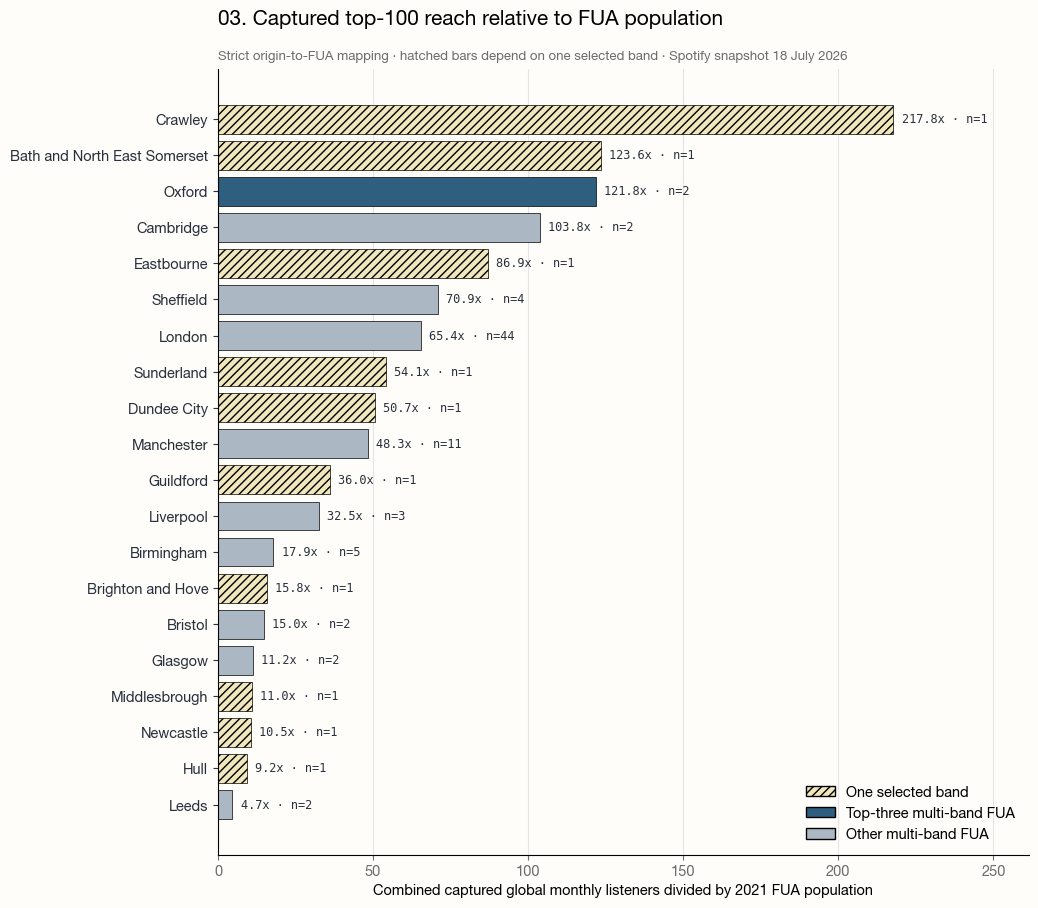

Exported to `artifacts/experiments/top100_popularity_first_fua/20260718T204522Z/chart_03_population_adjusted_fua_reach.png`.

Normalized rank,FUA,Selected bands,2021 population,Captured monthly listeners,Listeners / resident,Raw reach rank
1,Crawley,1,"118,607","25,827,890",217.76,8
2,Bath and North East Somerset,1,"192,419","23,781,006",123.59,9
3,Oxford,2,"576,725","70,261,364",121.83,4
4,Cambridge,2,"396,189","41,124,400",103.80,7
5,Eastbourne,1,"101,601","8,829,850",86.91,17
6,Sheffield,4,"1,168,389","82,887,435",70.94,3
7,London,44,"12,274,097","802,923,815",65.42,1
8,Sunderland,1,"274,378","14,843,560",54.10,11
9,Dundee City,1,"261,740","13,274,460",50.72,14
10,Manchester,11,"3,432,092","165,910,277",48.34,2


In [8]:
figure_03_path = plot_population_adjusted_fua_reach(
    strict,
    snapshot_date=snapshot_date,
    output_dir=CHART_OUTPUT_DIR,
)
display(Markdown(f"Exported to `{figure_03_path.relative_to(ROOT)}`."))

strict_table = ranked_strict[
    [
        "rank_by_listener_reach_per_resident",
        "study_city_label",
        "band_count",
        "population",
        "monthly_listeners_total",
        "top100_monthly_listeners_per_resident",
        "raw_reach_rank",
    ]
].rename(
    columns={
        "rank_by_listener_reach_per_resident": "Normalized rank",
        "study_city_label": "FUA",
        "band_count": "Selected bands",
        "population": "2021 population",
        "monthly_listeners_total": "Captured monthly listeners",
        "top100_monthly_listeners_per_resident": "Listeners / resident",
        "raw_reach_rank": "Raw reach rank",
    }
)
display(
    strict_table.style.hide(axis="index").format(
        {
            "2021 population": "{:,.0f}",
            "Captured monthly listeners": "{:,.0f}",
            "Listeners / resident": "{:.2f}",
        }
    )
)

**Reading the result.** Crawley moves from raw strict-FUA rank
8 to population-adjusted rank
1. Its numerator is one
band—**The Cure**. London moves from raw rank
1 to normalized rank
7; Manchester moves from
2 to
10. Population
normalization is therefore changing the question, not merely rescaling the
same league table.

## 06. Multi-band stability diagnostic

The complete strict ranking above is the main population-adjusted result. This
diagnostic narrows the display to FUAs represented by at least two selected
bands. It does not retroactively remove Crawley or redefine the top 100; it
shows which high rates have support beyond a single superstar.

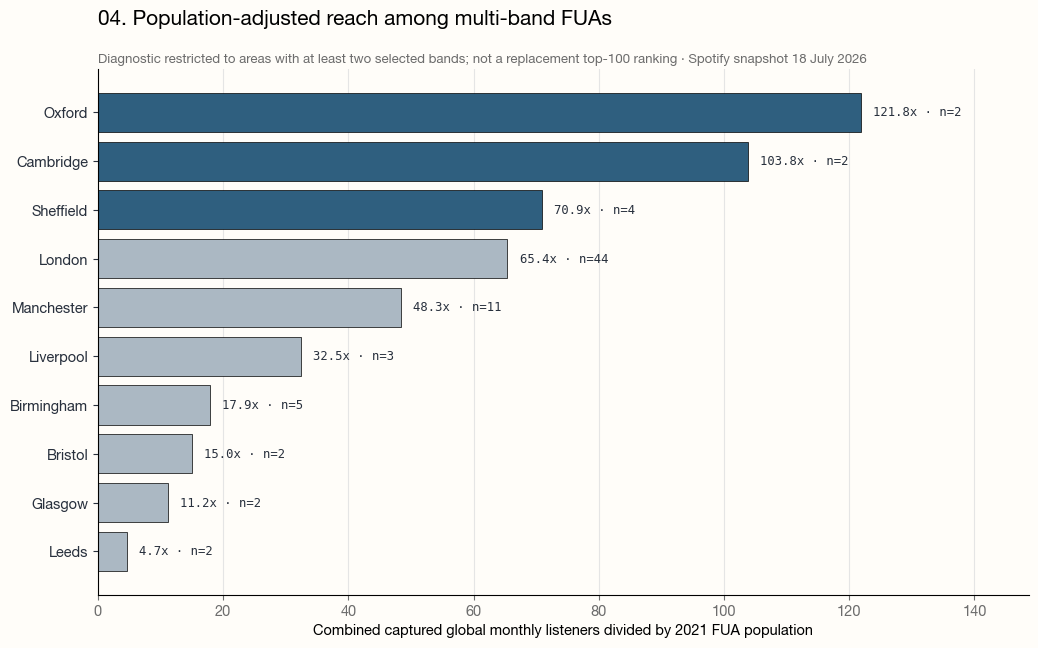

Exported to `artifacts/experiments/top100_popularity_first_fua/20260718T204522Z/chart_04_multiband_stability.png`.

FUA,Selected bands,Listeners / resident,Rank in full strict result
Oxford,2,121.83,3
Cambridge,2,103.80,4
Sheffield,4,70.94,6
London,44,65.42,7
Manchester,11,48.34,10
Liverpool,3,32.48,12
Birmingham,5,17.88,13
Bristol,2,14.96,15
Glasgow,2,11.16,16
Leeds,2,4.67,20


In [9]:
figure_04_path = plot_multiband_stability(
    strict,
    snapshot_date=snapshot_date,
    output_dir=CHART_OUTPUT_DIR,
)
display(Markdown(f"Exported to `{figure_04_path.relative_to(ROOT)}`."))

stable_table = (
    strict.loc[strict["band_count"].ge(2)]
    .sort_values("top100_monthly_listeners_per_resident", ascending=False)
    [
        [
            "study_city_label",
            "band_count",
            "top100_monthly_listeners_per_resident",
            "rank_by_listener_reach_per_resident",
        ]
    ]
    .rename(
        columns={
            "study_city_label": "FUA",
            "band_count": "Selected bands",
            "top100_monthly_listeners_per_resident": "Listeners / resident",
            "rank_by_listener_reach_per_resident": "Rank in full strict result",
        }
    )
)
display(
    stable_table.style.hide(axis="index").format(
        {"Listeners / resident": "{:.2f}"}
    )
)

Among FUAs with at least two selected bands, the leading three
are **Oxford, Cambridge, Sheffield**. This is a more stable reading of the
popularity-first sample, but it still is not a balanced scene-depth study:
London contributes 44 selected bands while Oxford and Cambridge contribute
two each.

## 07. What the denominator changes

The final chart compares the raw and population-adjusted ranks for exactly the
same 20 strict-mapped FUAs. It makes the denominator effect visible without
mixing in the broader reviewed mapping or dropping one-band cases.

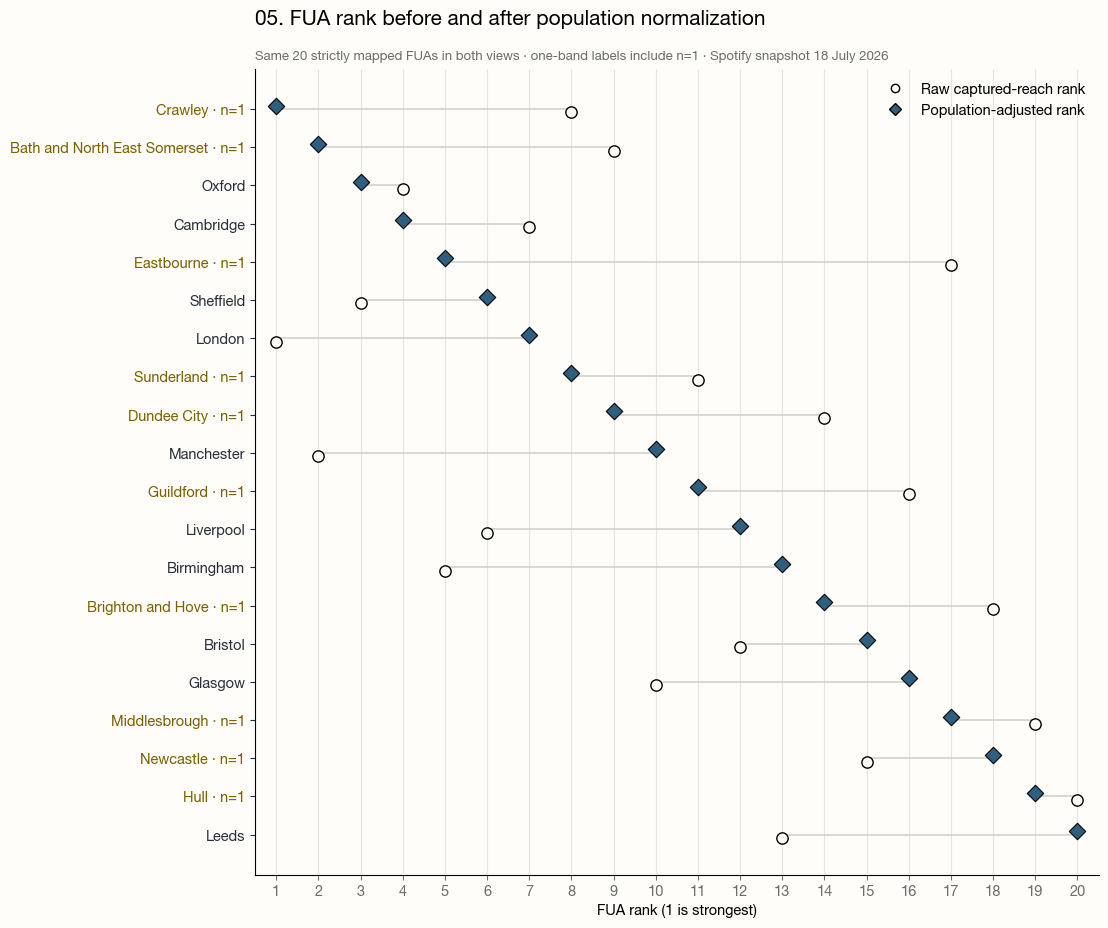

Exported to `artifacts/experiments/top100_popularity_first_fua/20260718T204522Z/chart_05_raw_vs_normalized_fua_ranks.png`.

In [10]:
figure_05_path = plot_raw_vs_normalized_fua_ranks(
    strict,
    snapshot_date=snapshot_date,
    output_dir=CHART_OUTPUT_DIR,
)
display(Markdown(f"Exported to `{figure_05_path.relative_to(ROOT)}`."))

## 08. Conclusion and limitations

The consolidated result is:

- **Raw scale:** London is the dominant origin in the selected top 100 and the
  largest strict-mapped FUA by captured reach.
- **Population-adjusted output:** Crawley ranks first because The Cure's global
  reach is large relative to Crawley's population.
- **Multi-band stability:** Oxford, Cambridge and Sheffield lead among FUAs
  with at least two selected bands.

These are complementary findings, not competing answers. Crawley is the most
interesting result precisely because it demonstrates both the value and the
risk of population normalization in a popularity-selected sample.

The conclusions remain narrow:

- The candidate frame inherits Wikidata coverage, classifications and Spotify
  ID quality; it is reproducible but not exhaustive.
- Monthly listeners are volatile current global reach, not historical impact,
  cultural influence, record sales or local listening.
- The top-100 cutoff creates selection sensitivity around the final qualifying
  bands.
- The strict FUA result maps 87 bands and 89.0% of captured reach. Unmapped
  bands are excluded from the denominator view rather than forced into a
  nearby FUA.
- Origin-to-FUA assignment is a boundary decision. Strict and broader reviewed
  mappings are kept separate.
- FUA population is from 2021 while Spotify reach was captured in 2026.
- One-band FUAs can rank highly from one globally dominant act. That is output
  per population, not scene depth.

## Appendix A. Extended mapping sensitivity

The broader view adds reviewed associations where an origin does not match an
FUA label directly. It covers more of the top 100 but embeds more geographic
judgment, so it is not promoted to the main chart. Crawley remains first.

In [11]:
comparison = strict[
    [
        "fua_code",
        "study_city_label",
        "band_count",
        "top100_monthly_listeners_per_resident",
        "rank_by_listener_reach_per_resident",
    ]
].merge(
    extended[
        [
            "fua_code",
            "study_city_label",
            "band_count",
            "top100_monthly_listeners_per_resident",
            "rank_by_listener_reach_per_resident",
        ]
    ],
    on=["fua_code", "study_city_label"],
    how="outer",
    suffixes=("_strict", "_extended"),
)
comparison["band_count_change"] = (
    comparison["band_count_extended"].fillna(0)
    - comparison["band_count_strict"].fillna(0)
)
comparison["rank_change"] = (
    comparison["rank_by_listener_reach_per_resident_strict"]
    - comparison["rank_by_listener_reach_per_resident_extended"]
)
changed = comparison.loc[
    comparison["band_count_change"].ne(0)
    | comparison["rank_change"].fillna(0).ne(0)
].sort_values(
    "rank_by_listener_reach_per_resident_extended",
    na_position="last",
)
display(
    changed.style.hide(axis="index").format(
        {
            "band_count_strict": "{:.0f}",
            "band_count_extended": "{:.0f}",
            "top100_monthly_listeners_per_resident_strict": "{:.2f}",
            "top100_monthly_listeners_per_resident_extended": "{:.2f}",
            "rank_by_listener_reach_per_resident_strict": "{:.0f}",
            "rank_by_listener_reach_per_resident_extended": "{:.0f}",
            "band_count_change": "{:+.0f}",
            "rank_change": "{:+.0f}",
        },
        na_rep="—",
    )
)

fua_code,study_city_label,band_count_strict,top100_monthly_listeners_per_resident_strict,rank_by_listener_reach_per_resident_strict,band_count_extended,top100_monthly_listeners_per_resident_extended,rank_by_listener_reach_per_resident_extended,band_count_change,rank_change
UK056F,Hastings,—,—,—,1,126.15,2,+1,—
UK031F,Bath and North East Somerset,1,123.59,2,1,123.59,3,+0,-1
UK560F,Oxford,2,121.83,3,2,121.83,4,+0,-1
UK017F,Cambridge,2,103.80,4,2,103.80,5,+0,-1
UK055F,Eastbourne,1,86.91,5,1,86.91,6,+0,-1
UK010F,Sheffield,4,70.94,6,4,70.94,7,+0,-1
UK033F,Guildford,1,36.05,11,2,70.62,8,+1,+3
UK001F,London,44,65.42,7,45,66.86,9,+1,-2
UK510F,Sunderland,1,54.10,8,1,54.10,10,+0,-2
UK550F,Dundee City,1,50.72,9,1,50.72,11,+0,-2


## Appendix B. Why there used to be two top-100 notebooks

The two predecessor notebooks are preserved as analysis history:

- `notebooks/experiments/snapshots/uk_bands_top100_popularity_first_20260718T204522Z.ipynb` established the raw popularity-first selection and
  origin-concentration result.
- `notebooks/experiments/snapshots/uk_bands_top100_popularity_first_population_adjusted_20260718T204522Z.ipynb` added the FUA population denominator and surfaced
  Crawley, but presented itself as a separate companion.

This notebook resolves that presentation duality by placing the raw result,
the strict population-adjusted result and the multi-band stability diagnostic
in one narrative. It does not overwrite either predecessor, change the frozen
top 100, refresh Spotify data or alter the city-first final notebook.